In [1]:
# === Cell 1: imports + load ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from econml.dml import LinearDML, CausalForestDML
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

ARTIFACTS = Path('data') / 'artifacts'

# Данные
train_df = pd.read_parquet(ARTIFACTS / 'train.parquet')
test_df  = pd.read_parquet(ARTIFACTS / 'test.parquet')
sku_info = pd.read_parquet(ARTIFACTS / 'sku_info.parquet')

# Уже обученные модели
gbm_demand = joblib.load(ARTIFACTS / 'gbm_demand.pkl')
cf_dml_price = joblib.load(ARTIFACTS / 'cf_dml.pkl')  # CATE по цене из Шага 3 (Model B)

# Если cost ещё не в датафреймах — merge
if 'cost' not in train_df.columns:
    train_df = train_df.merge(sku_info[['UPC', 'cost']], on='UPC', how='left')
if 'cost' not in test_df.columns:
    test_df  = test_df.merge(sku_info[['UPC', 'cost']],  on='UPC', how='left')

print(f'Train: {train_df.shape}')
print(f'Test : {test_df.shape}')

# promo_type distribution
print('\npromo_type distribution in train:')
print(train_df['promo_type'].value_counts(normalize=True).round(3))

Train: (150672, 41)
Test : (19004, 41)

promo_type distribution in train:
promo_type
none               0.757
tpr                0.111
feature_display    0.058
feature            0.040
display            0.033
Name: proportion, dtype: float64


In [2]:
# === Cell 2: DML для promo lift (discrete treatment) ===

# Treatment: promo_type как категория. EconML принимает 1D массив строк/чисел.
# Возьмём 'none' как референс (нулевой уровень)

promo_order = ['none', 'tpr', 'display', 'feature', 'feature_display']
promo_to_code = {p: i for i, p in enumerate(promo_order)}

T_promo = train_df['promo_type'].map(promo_to_code).values  # 0..4

# Outcome: log_units
Y = train_df['log_units'].values

# Контроли: ВСЁ, что у нас есть, ВКЛЮЧАЯ log_price.
# Это важно: эффект promo_type должен быть оценён при фиксированной цене,
# иначе мы припишем promo тот эффект, который реально дала скидка.
CONTROLS_FOR_PROMO = [
    'log_price',                                                    # ← цена в контролях
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code',
    'size_oz',
    'month', 'week_of_year', 'quarter', 'year', 'is_holiday_week',
    'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS',
]
W = train_df[CONTROLS_FOR_PROMO].values

print(f'Y shape: {Y.shape}')
print(f'T shape: {T_promo.shape}, unique values: {np.unique(T_promo)}')
print(f'W shape: {W.shape}')

# Nuisance-модели
# Для outcome — LightGBM регрессия (как раньше)
model_y_promo = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)
# Для treatment — классификатор (потому что T дискретный), Random Forest
model_t_promo = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=100, max_features='sqrt',
    n_jobs=-1, random_state=42,
)

# LinearDML с discrete_treatment=True
# Это даст нам "плоские" коэффициенты — общий promo lift для каждого уровня vs референс
est_promo = LinearDML(
    model_y=model_y_promo,
    model_t=model_t_promo,
    discrete_treatment=True,
    cv=5,
    random_state=42,
)

print('\nFitting LinearDML for promo_type (это займёт пару минут)...')
import time
t0 = time.time()
est_promo.fit(Y, T_promo, X=None, W=W)
print(f'Done in {time.time() - t0:.1f}s.')

# Эффект каждого promo_type vs 'none'
# В discrete_treatment модели intercept — это эффект каждого уровня
print('\n=== Promo lift estimates (vs none) ===')
summary = est_promo.summary()
print(summary)

Y shape: (150672,)
T shape: (150672,), unique values: [0 1 2 3 4]
W shape: (150672, 14)

Fitting LinearDML for promo_type (это займёт пару минут)...
Done in 14.8s.

=== Promo lift estimates (vs none) ===
Coefficient Results:  X is None, please call intercept_inference to learn the constant!
                          CATE Intercept Results                          
                    point_estimate stderr  zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------------
cate_intercept|T0_1         -0.069  0.006 -12.037    0.0    -0.08   -0.057
cate_intercept|T0_2          0.356  0.008  43.334    0.0     0.34    0.372
cate_intercept|T0_3          0.357  0.009  40.334    0.0     0.34    0.375
cate_intercept|T0_4          0.727  0.008  89.691    0.0    0.711    0.743
--------------------------------------------------------------------------

<sub>A linear parametric conditional average treatment effect (CATE) model was fitted:
$Y = \Theta(X)\cdot 

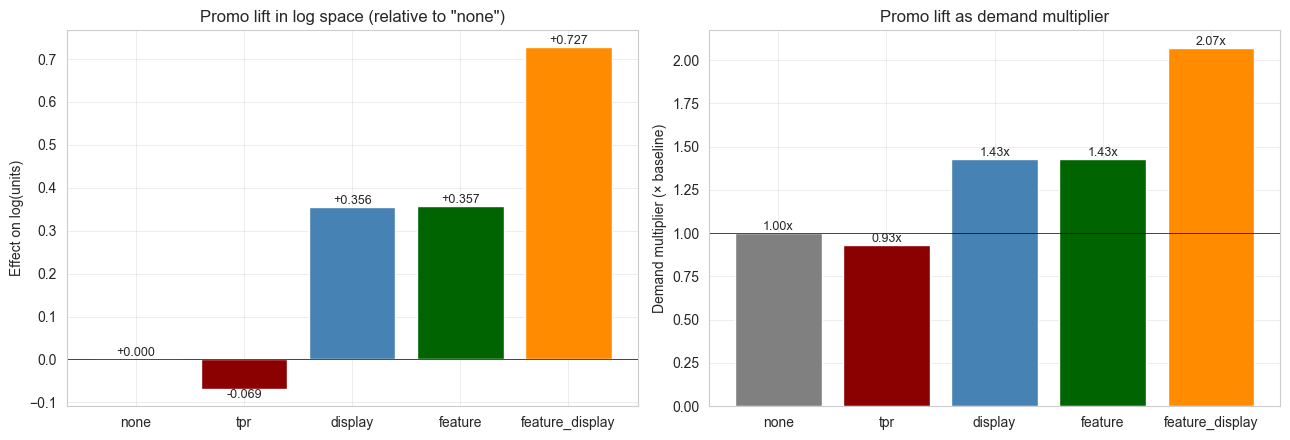

Saved promo lifts → data/artifacts/promo_lift.json

=== Promo usage vs effectiveness ===
     promo_type  usage_share demand_lift_pct  log_effect
           none     0.757413           +0.0%       0.000
            tpr     0.111255           -6.7%      -0.069
        display     0.033324          +42.8%       0.356
        feature     0.040041          +42.9%       0.357
feature_display     0.057967         +106.9%       0.727


In [3]:
# === Cell 3: visualize promo lifts + business взгляд ===

# Достанем coefficients из est_promo
promo_lift_log = {
    'none':            0.0,                    # референс
    'tpr':            -0.069,
    'display':         0.356,
    'feature':         0.357,
    'feature_display': 0.727,
}

# Перевод в мультипликатор спроса (exp)
promo_lift_mult = {k: np.exp(v) for k, v in promo_lift_log.items()}

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = ['none', 'tpr', 'display', 'feature', 'feature_display']

# График 1: в логах (как из модели)
axes[0].bar(order, [promo_lift_log[k] for k in order],
            color=['gray', 'darkred', 'steelblue', 'darkgreen', 'darkorange'])
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_ylabel('Effect on log(units)')
axes[0].set_title('Promo lift in log space (relative to "none")')
for i, k in enumerate(order):
    axes[0].annotate(f'{promo_lift_log[k]:+.3f}', xy=(i, promo_lift_log[k]),
                     ha='center', va='bottom' if promo_lift_log[k]>=0 else 'top', fontsize=9)

# График 2: мультипликаторы
axes[1].bar(order, [promo_lift_mult[k] for k in order],
            color=['gray', 'darkred', 'steelblue', 'darkgreen', 'darkorange'])
axes[1].axhline(1, color='black', linewidth=0.5)
axes[1].set_ylabel('Demand multiplier (× baseline)')
axes[1].set_title('Promo lift as demand multiplier')
for i, k in enumerate(order):
    axes[1].annotate(f'{promo_lift_mult[k]:.2f}x', xy=(i, promo_lift_mult[k]),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Сохраним в артефакты для оптимизатора
import json
with open(ARTIFACTS / 'promo_lift.json', 'w') as f:
    json.dump(promo_lift_log, f, indent=2)
print(f'Saved promo lifts → {ARTIFACTS / "promo_lift.json"}')

# Bonus: какие промо исторически чаще ставит ритейлер? Имеют ли они смысл?
print('\n=== Promo usage vs effectiveness ===')
usage = train_df['promo_type'].value_counts(normalize=True).reindex(order).fillna(0)
print(pd.DataFrame({
    'promo_type'         : order,
    'usage_share'        : usage.values,
    'demand_lift_pct'    : [f'{(promo_lift_mult[k]-1)*100:+.1f}%' for k in order],
    'log_effect'         : [promo_lift_log[k] for k in order],
}).to_string(index=False))

In [4]:
# === Cell 4: эмпирические bounds для каждой (UPC, promo_type) пары ===

# Для каждой комбинации (UPC, promo_type) считаем p5 и p95 цен в обучающих данных
# Это и есть "реалистичный" диапазон, в котором эта комбинация исторически наблюдалась
bounds_table = (
    train_df.groupby(['UPC', 'promo_type'])['PRICE']
    .agg(['min', 'max', 'count',
          lambda x: x.quantile(0.05),
          lambda x: x.quantile(0.95)])
    .rename(columns={'<lambda_0>': 'p05', '<lambda_1>': 'p95'})
    .reset_index()
)
bounds_table.columns = ['UPC', 'promo_type', 'price_min', 'price_max',
                         'n_observations', 'price_p05', 'price_p95']

print(f'Total (UPC, promo_type) combinations: {len(bounds_table)}')
print(f'Combinations with < 30 observations  : {(bounds_table["n_observations"] < 30).sum()}')
print('(такие комбинации редкие, будем считать их недопустимыми)')

# Для примера — посмотрим на одно SKU
example_upc = 1600027528  # GM CHEERIOS 18 oz
print(f'\n=== Price bounds for UPC {example_upc} (GM CHEERIOS 18 oz) ===')
print(bounds_table[bounds_table['UPC'] == example_upc].to_string(index=False))

# И — для частоты использования
print(f'\n=== Frequency of (UPC, promo) — sample of brand SKUs ===')
print(bounds_table[bounds_table['UPC'].isin([1600027528, 3800039118, 1111085319])]
      .sort_values(['UPC', 'promo_type']).to_string(index=False))

# Сохраним bounds-таблицу
bounds_table.to_parquet(ARTIFACTS / 'price_bounds_by_promo.parquet', index=False)
print(f'\nSaved → {ARTIFACTS / "price_bounds_by_promo.parquet"}')

Total (UPC, promo_type) combinations: 75
Combinations with < 30 observations  : 0
(такие комбинации редкие, будем считать их недопустимыми)

=== Price bounds for UPC 1600027528 (GM CHEERIOS 18 oz) ===
       UPC      promo_type  price_min  price_max  n_observations  price_p05  price_p95
1600027528         display       2.38       4.79             175     2.4700     4.6500
1600027528         feature       1.76       4.36             235     2.2300     3.8900
1600027528 feature_display       2.16       4.32             728     2.4800     3.3600
1600027528            none       3.06       5.19            9171     4.1500     4.7900
1600027528             tpr       1.50       4.59             134     2.4865     4.1235

=== Frequency of (UPC, promo) — sample of brand SKUs ===
       UPC      promo_type  price_min  price_max  n_observations  price_p05  price_p95
1111085319         display       1.11       1.99             205     1.5000     1.8900
1111085319         feature       1.40       1

In [5]:
# === Cell 5: переучить CausalForestDML для чистой ценовой эластичности (Model A) ===

# Контроли — те же, что для promo lift (включают promo_type)
CONTROLS_A = [
    'upc_code', 'store_code', 'manuf_code', 'subcat_code', 'seg_code',
    'size_oz',
    'month', 'week_of_year', 'quarter', 'year', 'is_holiday_week',
    'promo_code',   # ← promo в контролях
    'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS',
]
EFFECT_MODIFIERS = ['manuf_code', 'subcat_code', 'seg_code', 'size_oz']
NUISANCE_A = [c for c in CONTROLS_A if c not in EFFECT_MODIFIERS]

X_em = train_df[EFFECT_MODIFIERS].values
W_a  = train_df[NUISANCE_A].values
T    = train_df['log_price'].values
Y    = train_df['log_units'].values

print(f'X (effect modifiers): {X_em.shape}')
print(f'W (nuisance + promo): {W_a.shape}')

model_y_a = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)
model_t_a = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=100, feature_fraction=0.8, random_state=42, verbose=-1,
)

cf_dml_a = CausalForestDML(
    model_y=model_y_a, model_t=model_t_a,
    discrete_treatment=False,
    n_estimators=200, min_samples_leaf=200,
    cv=5, random_state=42,
)

print('\nFitting CausalForestDML — Model A (clean price elasticity)...')
import time
t0 = time.time()
cf_dml_a.fit(Y, T, X=X_em, W=W_a)
print(f'Done in {time.time() - t0:.1f}s.')

# Эластичности на train
cate_a = cf_dml_a.effect(X_em)
print(f'\n=== Pure price CATE (Model A) — Cheerios is no longer "bundled" with promo ===')
print(f'Mean elasticity   : {cate_a.mean():+.3f}')
print(f'Median elasticity : {np.median(cate_a):+.3f}')
print(f'Std               : {cate_a.std():.3f}')
print(f'Min / Max         : {cate_a.min():+.3f} / {cate_a.max():+.3f}')

# Сравнение с Model B
print(f'\n=== Comparison ===')
print(f'Model A (clean price)        mean: {cate_a.mean():+.3f}  ← для оптимизатора')
print(f'Model B (price+promo bundle) mean: -2.62                ← biased для нашей задачи')
print(f'EconML LinearDML Model A         : -1.55                ← average estimate')

# Сохраним
joblib.dump(cf_dml_a, ARTIFACTS / 'cf_dml_model_a.pkl')
print(f'\nSaved → {ARTIFACTS / "cf_dml_model_a.pkl"}')

X (effect modifiers): (150672, 4)
W (nuisance + promo): (150672, 10)

Fitting CausalForestDML — Model A (clean price elasticity)...
Done in 14.1s.

=== Pure price CATE (Model A) — Cheerios is no longer "bundled" with promo ===
Mean elasticity   : -1.796
Median elasticity : -1.830
Std               : 0.635
Min / Max         : -3.105 / -0.052

=== Comparison ===
Model A (clean price)        mean: -1.796  ← для оптимизатора
Model B (price+promo bundle) mean: -2.62                ← biased для нашей задачи
EconML LinearDML Model A         : -1.55                ← average estimate

Saved → data/artifacts/cf_dml_model_a.pkl


In [6]:
# === Cell 6: Joint optimizer (price × promo), векторизованный ===

# Загружаем promo lifts
import json
with open(ARTIFACTS / 'promo_lift.json') as f:
    promo_lift_log = json.load(f)

PROMO_ORDER = ['none', 'tpr', 'display', 'feature', 'feature_display']
promo_lifts_array = np.array([promo_lift_log[p] for p in PROMO_ORDER])  # shape [M=5]
print('Promo lifts (log effect):')
for p, l in zip(PROMO_ORDER, promo_lifts_array):
    print(f'  {p:>16}: {l:+.3f}  (×{np.exp(l):.2f})')

# Загружаем bounds таблицу
bounds_df = pd.read_parquet(ARTIFACTS / 'price_bounds_by_promo.parquet')
# Превратим в lookup dict: (UPC, promo_type) -> (p05, p95)
bounds_dict = {
    (row['UPC'], row['promo_type']): (row['price_p05'], row['price_p95'])
    for _, row in bounds_df.iterrows()
}

N_PRICE_GRID = 40  # точек ценовой сетки внутри bounds

def joint_optimize(rows_df, cf_price=cf_dml_a, gbm=gbm_demand):
    """
    Совместная оптимизация (цена × promo_type) для всех строк rows_df.

    Возвращает DataFrame с колонками:
      optimal_price, optimal_promo, optimal_units_pred, optimal_profit_model,
      hist_units_pred, hist_profit_model
    """
    N = len(rows_df)
    M = len(PROMO_ORDER)
    K = N_PRICE_GRID

    feature_cols = gbm.feature_name_

    # === 1. Baseline для каждой строки: предсказание GBM на исторических (p, m) ===
    log_units_baseline = gbm.predict(rows_df[feature_cols])  # shape [N]
    price_hist = rows_df['PRICE'].values                      # shape [N]
    promo_hist = rows_df['promo_type'].values                 # shape [N]
    costs = rows_df['cost'].values                            # shape [N]

    # === 2. Чистая ценовая эластичность для каждой строки ===
    em = rows_df[EFFECT_MODIFIERS].values
    theta_price = cf_price.effect(em)                          # shape [N]

    # === 3. promo_lift для каждой строки в её историческом m ===
    promo_lift_hist = np.array([promo_lift_log[p] for p in promo_hist])  # shape [N]

    # === 4. Матрица допустимых цен [N × K × M] ===
    # Для каждой (строка, promo) — линспейс в её bounds
    # Промо-цены могут варьироваться, поэтому строим отдельную сетку для каждой (строки, promo)
    upc_arr = rows_df['UPC'].values

    price_grids = np.zeros((N, K, M))
    valid_mask  = np.zeros((N, M), dtype=bool)  # есть ли допустимые bounds для (i, m)

    for m_idx, m_name in enumerate(PROMO_ORDER):
        for i in range(N):
            key = (upc_arr[i], m_name)
            if key in bounds_dict:
                p05, p95 = bounds_dict[key]
                if p05 < p95 and p05 > costs[i]:  # bounds валидные и выше cost
                    price_grids[i, :, m_idx] = np.linspace(p05, p95, K)
                    valid_mask[i, m_idx] = True
                else:
                    price_grids[i, :, m_idx] = np.nan
            else:
                price_grids[i, :, m_idx] = np.nan

    # === 5. Прогноз спроса для каждой [N, K, M] ячейки ===
    # log_units(p, m) = baseline + θ × (log p − log p_hist) + (promo_lift[m] − promo_lift[m_hist])
    log_p_hist = np.log(price_hist).reshape(N, 1, 1)
    theta_3d   = theta_price.reshape(N, 1, 1)
    baseline_3d = log_units_baseline.reshape(N, 1, 1)
    promo_lift_3d = promo_lifts_array.reshape(1, 1, M)
    promo_lift_hist_3d = promo_lift_hist.reshape(N, 1, 1)

    with np.errstate(invalid='ignore', divide='ignore'):
        log_p_grid = np.log(price_grids)                                       # [N, K, M]
        log_units_pred = (baseline_3d
                         + theta_3d * (log_p_grid - log_p_hist)
                         + promo_lift_3d - promo_lift_hist_3d)
        units_pred = np.exp(log_units_pred)                                    # [N, K, M]
        profit = (price_grids - costs.reshape(N, 1, 1)) * units_pred           # [N, K, M]

    # Маскируем недопустимые
    profit = np.where(np.isnan(price_grids), -np.inf, profit)

    # === 6. Argmax по всем [K × M] для каждой строки ===
    profit_flat = profit.reshape(N, K * M)
    best_idx = profit_flat.argmax(axis=1)
    best_k = best_idx // M
    best_m = best_idx % M

    optimal_price  = price_grids[np.arange(N), best_k, best_m]
    optimal_units  = units_pred[np.arange(N), best_k, best_m]
    optimal_profit = profit[np.arange(N), best_k, best_m]
    optimal_promo  = np.array(PROMO_ORDER)[best_m]

    # === 7. Historical baseline (для честного uplift) ===
    hist_units = np.exp(log_units_baseline)
    hist_profit = (price_hist - costs) * hist_units

    return pd.DataFrame({
        'optimal_price'       : optimal_price,
        'optimal_promo'       : optimal_promo,
        'optimal_units_pred'  : optimal_units,
        'optimal_profit_model': optimal_profit,
        'theta_price'         : theta_price,
        'hist_units_pred'     : hist_units,
        'hist_profit_model'   : hist_profit,
    }, index=rows_df.index)


print('\nOptimizing test set...')
import time
t0 = time.time()
opt = joint_optimize(test_df)
print(f'Done in {time.time() - t0:.1f}s.')

# Merge с test
test_opt = test_df.join(opt, how='left')
test_opt['uplift_abs'] = test_opt['optimal_profit_model'] - test_opt['hist_profit_model']
test_opt['uplift_pct'] = test_opt['uplift_abs'] / test_opt['hist_profit_model'] * 100
test_opt['price_change_pct'] = (test_opt['optimal_price'] - test_opt['PRICE']) / test_opt['PRICE'] * 100

# === Aggregate ===
print('\n=== Joint optimizer — aggregate results ===')
total_uplift_pct = test_opt['uplift_abs'].sum() / test_opt['hist_profit_model'].sum() * 100
print(f'Total historical profit (model): ${test_opt["hist_profit_model"].sum():,.0f}')
print(f'Total optimal profit (model)   : ${test_opt["optimal_profit_model"].sum():,.0f}')
print(f'Total uplift                   : ${test_opt["uplift_abs"].sum():,.0f}  ({total_uplift_pct:+.2f}%)')

print(f'\n=== Per-row distribution ===')
print(f'Median uplift per row : {test_opt["uplift_pct"].median():+.2f}%')
print(f'Mean uplift per row   : {test_opt["uplift_pct"].mean():+.2f}%')

print(f'\n=== Promo recommendation distribution ===')
print('Historical promo_type:')
print(test_df['promo_type'].value_counts(normalize=True).round(3))
print('\nOptimal promo_type:')
print(test_opt['optimal_promo'].value_counts(normalize=True).round(3))

Promo lifts (log effect):
              none: +0.000  (×1.00)
               tpr: -0.069  (×0.93)
           display: +0.356  (×1.43)
           feature: +0.357  (×1.43)
   feature_display: +0.727  (×2.07)

Optimizing test set...
Done in 0.5s.

=== Joint optimizer — aggregate results ===
Total historical profit (model): $435,335
Total optimal profit (model)   : $641,143
Total uplift                   : $205,808  (+47.28%)

=== Per-row distribution ===
Median uplift per row : +37.77%
Mean uplift per row   : +58.61%

=== Promo recommendation distribution ===
Historical promo_type:
promo_type
none               0.808
tpr                0.098
feature_display    0.043
feature            0.033
display            0.018
Name: proportion, dtype: float64

Optimal promo_type:
optimal_promo
none               0.499
feature_display    0.258
display            0.243
Name: proportion, dtype: float64


In [7]:
# === Cell 7: Capacity-constrained joint optimizer ===

# Бюджеты = историческое распределение (в долях строк)
CAPACITY = {
    'none'           : 1.0,    # без ограничения — всегда доступно
    'tpr'            : test_df['promo_type'].eq('tpr').mean(),
    'display'        : test_df['promo_type'].eq('display').mean(),
    'feature'        : test_df['promo_type'].eq('feature').mean(),
    'feature_display': test_df['promo_type'].eq('feature_display').mean(),
}
print('Capacity (= historical share):')
for k, v in CAPACITY.items():
    print(f'  {k:>16}: {v:.3f}  ≈ {int(v * len(test_df))} slots')


def joint_optimize_constrained(rows_df, cf_price=cf_dml_a, gbm=gbm_demand, capacity=CAPACITY):
    """
    Joint optimizer с capacity constraints через жадный алгоритм.

    Логика:
    1. Для каждой строки и каждого promo m вычисляем оптимальную цену p*(i, m) и прибыль profit*(i, m)
    2. Для каждого promo m с лимитом считаем uplift_marginal[i] = profit*(i, m) − profit*(i, none)
    3. Сортируем строки по uplift_marginal[i] убыванию, отдаём слоты топовым
    4. Каждая строка может получить только один promo (или none)
    """
    N = len(rows_df)
    M = len(PROMO_ORDER)
    K = N_PRICE_GRID

    # === Шаг 1: для каждой (строка, promo) — оптимальная цена и прибыль ===
    # (это переиспользование логики из Cell 6, но мы хотим знать профит ПО КАЖДОМУ promo, не argmax)
    feature_cols = gbm.feature_name_
    log_units_baseline = gbm.predict(rows_df[feature_cols])
    price_hist = rows_df['PRICE'].values
    promo_hist = rows_df['promo_type'].values
    costs = rows_df['cost'].values
    upc_arr = rows_df['UPC'].values

    em = rows_df[EFFECT_MODIFIERS].values
    theta_price = cf_price.effect(em)
    promo_lift_hist = np.array([promo_lift_log[p] for p in promo_hist])

    # Матрица [N × M] — лучшая прибыль для каждой (строка, promo)
    best_profit_per_promo = np.full((N, M), -np.inf)
    best_price_per_promo  = np.full((N, M), np.nan)
    best_units_per_promo  = np.full((N, M), np.nan)

    for m_idx, m_name in enumerate(PROMO_ORDER):
        # Строим сетку цен внутри bounds для этого promo
        price_grid = np.full((N, K), np.nan)
        for i in range(N):
            key = (upc_arr[i], m_name)
            if key in bounds_dict:
                p05, p95 = bounds_dict[key]
                if p05 < p95 and p05 > costs[i]:
                    price_grid[i] = np.linspace(p05, p95, K)

        log_p_grid = np.log(price_grid)                                   # [N, K]
        log_p_hist_col = np.log(price_hist).reshape(N, 1)                  # [N, 1]

        with np.errstate(invalid='ignore'):
            log_units_pred = (log_units_baseline.reshape(N, 1)
                             + theta_price.reshape(N, 1) * (log_p_grid - log_p_hist_col)
                             + promo_lifts_array[m_idx] - promo_lift_hist.reshape(N, 1))
            units_pred = np.exp(log_units_pred)
            profit = (price_grid - costs.reshape(N, 1)) * units_pred

        profit = np.where(np.isnan(price_grid), -np.inf, profit)
        best_k = profit.argmax(axis=1)
        best_profit_per_promo[:, m_idx] = profit[np.arange(N), best_k]
        best_price_per_promo[:, m_idx]  = price_grid[np.arange(N), best_k]
        best_units_per_promo[:, m_idx]  = units_pred[np.arange(N), best_k]

    # === Шаг 2: жадное распределение слотов promo по приоритету uplift ===
    # Каждая строка изначально получает 'none' как fallback
    none_idx = PROMO_ORDER.index('none')
    assigned_promo_idx = np.full(N, none_idx)

    # Считаем marginal uplift каждого premium-promo (vs none)
    # Промо обрабатываем в порядке убывания эффекта (feature_display первый)
    premium_promos = sorted(
        [(m_idx, m_name) for m_idx, m_name in enumerate(PROMO_ORDER) if m_name not in ('none', 'tpr')],
        key=lambda x: -promo_lifts_array[x[0]],
    )

    assigned = np.zeros(N, dtype=bool)  # строка уже получила что-то лучше чем none

    for m_idx, m_name in premium_promos:
        n_slots = int(capacity[m_name] * N)
        # Считаем uplift для строк, которые ещё не assigned
        uplift = best_profit_per_promo[:, m_idx] - best_profit_per_promo[:, none_idx]
        uplift = np.where(assigned, -np.inf, uplift)  # уже занятые не рассматриваем
        uplift = np.where(np.isinf(best_profit_per_promo[:, m_idx]), -np.inf, uplift)

        # Топ-n строк
        top_idx = np.argsort(-uplift)[:n_slots]
        # Берём только те, у которых uplift > 0
        top_idx = top_idx[uplift[top_idx] > 0]

        assigned_promo_idx[top_idx] = m_idx
        assigned[top_idx] = True

    # === Шаг 3: финальные результаты ===
    final_price  = best_price_per_promo[np.arange(N), assigned_promo_idx]
    final_units  = best_units_per_promo[np.arange(N), assigned_promo_idx]
    final_profit = best_profit_per_promo[np.arange(N), assigned_promo_idx]
    final_promo  = np.array(PROMO_ORDER)[assigned_promo_idx]

    # Historical baseline
    hist_units = np.exp(log_units_baseline)
    hist_profit = (price_hist - costs) * hist_units

    return pd.DataFrame({
        'optimal_price'       : final_price,
        'optimal_promo'       : final_promo,
        'optimal_units_pred'  : final_units,
        'optimal_profit_model': final_profit,
        'theta_price'         : theta_price,
        'hist_units_pred'     : hist_units,
        'hist_profit_model'   : hist_profit,
    }, index=rows_df.index)


print('\nRunning capacity-constrained optimizer...')
import time
t0 = time.time()
opt_c = joint_optimize_constrained(test_df)
print(f'Done in {time.time() - t0:.1f}s.')

test_opt_c = test_df.join(opt_c, how='left')
test_opt_c['uplift_abs'] = test_opt_c['optimal_profit_model'] - test_opt_c['hist_profit_model']
test_opt_c['uplift_pct'] = test_opt_c['uplift_abs'] / test_opt_c['hist_profit_model'] * 100
test_opt_c['price_change_pct'] = (test_opt_c['optimal_price'] - test_opt_c['PRICE']) / test_opt_c['PRICE'] * 100

# === Aggregate ===
print('\n=== Capacity-constrained joint optimizer — aggregate ===')
total_uplift = test_opt_c['uplift_abs'].sum() / test_opt_c['hist_profit_model'].sum() * 100
print(f'Total historical profit (model): ${test_opt_c["hist_profit_model"].sum():,.0f}')
print(f'Total optimal profit (model)   : ${test_opt_c["optimal_profit_model"].sum():,.0f}')
print(f'Total uplift                   : ${test_opt_c["uplift_abs"].sum():,.0f}  ({total_uplift:+.2f}%)')

print(f'\n=== Per-row uplift distribution ===')
print(f'Median: {test_opt_c["uplift_pct"].median():+.2f}%')
print(f'Mean  : {test_opt_c["uplift_pct"].mean():+.2f}%')
print(f'p25/p75: {test_opt_c["uplift_pct"].quantile(0.25):+.2f}% / {test_opt_c["uplift_pct"].quantile(0.75):+.2f}%')

print(f'\n=== Promo distribution comparison ===')
hist_promo = test_df['promo_type'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0)
unc_promo  = test_opt['optimal_promo'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0)
con_promo  = test_opt_c['optimal_promo'].value_counts(normalize=True).reindex(PROMO_ORDER).fillna(0)

promo_df = pd.DataFrame({
    'historical': hist_promo,
    'unconstrained': unc_promo,
    'constrained': con_promo,
}).round(3)
print(promo_df)

Capacity (= historical share):
              none: 1.000  ≈ 19004 slots
               tpr: 0.098  ≈ 1856 slots
           display: 0.018  ≈ 345 slots
           feature: 0.033  ≈ 631 slots
   feature_display: 0.043  ≈ 822 slots

Running capacity-constrained optimizer...
Done in 0.4s.

=== Capacity-constrained joint optimizer — aggregate ===
Total historical profit (model): $435,335
Total optimal profit (model)   : $568,234
Total uplift                   : $132,900  (+30.53%)

=== Per-row uplift distribution ===
Median: +9.03%
Mean  : +30.88%
p25/p75: +0.54% / +30.33%

=== Promo distribution comparison ===
                 historical  unconstrained  constrained
none                  0.808          0.499        0.905
tpr                   0.098          0.000        0.000
display               0.018          0.243        0.018
feature               0.033          0.000        0.033
feature_display       0.043          0.258        0.043


In [8]:
# === Cell 8: диагностика — почему uplift такой высокий ===

# 1) Распределение uplift по тому, что рекомендует оптимизатор
print('=== Uplift by recommended promo (constrained) ===')
diag = test_opt_c.groupby('optimal_promo').agg(
    n              =('uplift_pct', 'size'),
    median_uplift  =('uplift_pct', 'median'),
    mean_uplift    =('uplift_pct', 'mean'),
    median_price_change=('price_change_pct', 'median'),
).round(2)
print(diag)

# 2) Распределение uplift по парам (historical_promo → recommended_promo)
print('\n=== Uplift by transition: was → recommended ===')
trans = test_opt_c.groupby(['promo_type', 'optimal_promo']).agg(
    n          =('uplift_pct', 'size'),
    mean_uplift=('uplift_pct', 'mean'),
).round(2)
print(trans.to_string())

# 3) Top-20 строк с самым большим uplift — что там происходит?
print('\n=== Top-20 strongest uplift cases ===')
top_uplift = test_opt_c.nlargest(20, 'uplift_pct')[[
    'DESCRIPTION', 'STORE_NUM', 'PRICE', 'optimal_price',
    'promo_type', 'optimal_promo',
    'UNITS', 'hist_units_pred', 'optimal_units_pred',
    'hist_profit_model', 'optimal_profit_model', 'uplift_pct',
]].round(2)
print(top_uplift.to_string(index=False))

# 4) Контрольная цифра — какой uplift, если оптимизатор только меняет цену, оставляя promo как было?
# Это будет "лимит снизу" — uplift от чистого price optimization, без перераспределения promo
print('\n=== Counterfactual: только price optimization, без смены promo ===')

def price_only_optimize(rows_df, cf_price=cf_dml_a, gbm=gbm_demand):
    """Оптимизирует только цену, сохраняя исторический promo_type."""
    N = len(rows_df)
    K = N_PRICE_GRID
    feature_cols = gbm.feature_name_
    log_units_baseline = gbm.predict(rows_df[feature_cols])
    price_hist = rows_df['PRICE'].values
    promo_hist = rows_df['promo_type'].values
    costs = rows_df['cost'].values
    upc_arr = rows_df['UPC'].values

    em = rows_df[EFFECT_MODIFIERS].values
    theta_price = cf_price.effect(em)

    # Для каждой строки строим bounds для её исторического promo
    price_grid = np.full((N, K), np.nan)
    for i in range(N):
        key = (upc_arr[i], promo_hist[i])
        if key in bounds_dict:
            p05, p95 = bounds_dict[key]
            if p05 < p95 and p05 > costs[i]:
                price_grid[i] = np.linspace(p05, p95, K)

    log_p_grid = np.log(price_grid)
    log_p_hist = np.log(price_hist).reshape(N, 1)

    with np.errstate(invalid='ignore'):
        log_units_pred = (log_units_baseline.reshape(N, 1)
                         + theta_price.reshape(N, 1) * (log_p_grid - log_p_hist))
        units_pred = np.exp(log_units_pred)
        profit = (price_grid - costs.reshape(N, 1)) * units_pred

    profit = np.where(np.isnan(price_grid), -np.inf, profit)
    best_k = profit.argmax(axis=1)

    optimal_profit = profit[np.arange(N), best_k]
    hist_profit = (price_hist - costs) * np.exp(log_units_baseline)

    return optimal_profit, hist_profit

opt_p, hist_p = price_only_optimize(test_df)
price_only_uplift = (opt_p.sum() / hist_p.sum() - 1) * 100
print(f'Price-only uplift (no promo change): {price_only_uplift:+.2f}%')
print(f'Joint constrained uplift           : +30.53%')
print(f'Joint unconstrained uplift         : +47.28%')
print(f'\nИнтерпретация:')
print('  - Price-only uplift          ← реалистичный вклад от изменения цены')
print('  - Joint - Price-only         ← вклад от перераспределения promo (то, что добавил наш оптимизатор)')

=== Uplift by recommended promo (constrained) ===
                     n  median_uplift  mean_uplift  median_price_change
optimal_promo                                                          
display            345          26.76        33.43               -15.42
feature            631          37.26        38.07               -13.92
feature_display    822          82.97        85.39               -15.23
none             17206           7.53        27.96                 7.55

=== Uplift by transition: was → recommended ===
                                     n  mean_uplift
promo_type      optimal_promo                      
display         display              2        -8.66
                feature              1        -9.45
                feature_display      2        15.54
                none               340       -36.08
feature         display              1       271.46
                feature              1         2.51
                none               629        -0.54
f

In [9]:
# Быстрая проверка
sample_row = test_opt_c.loc[test_opt_c['uplift_pct'].idxmax()]
print(f"DESCRIPTION: {sample_row['DESCRIPTION']}")
print(f"UPC        : {sample_row['UPC']}")
print(f"PRICE      : ${sample_row['PRICE']:.2f}")
print(f"cost       : ${sample_row['cost']:.4f}")
print(f"margin     : ${sample_row['PRICE'] - sample_row['cost']:.4f}")
print(f"hist_units : {sample_row['hist_units_pred']:.2f}")
print(f"calc_profit: ${(sample_row['PRICE'] - sample_row['cost']) * sample_row['hist_units_pred']:.4f}")
print(f"reported   : ${sample_row['hist_profit_model']:.4f}")

DESCRIPTION: GM CHEERIOS
UPC        : 1600027564
PRICE      : $2.22
cost       : $2.2190
margin     : $0.0010
hist_units : 24.74
calc_profit: $0.0247
reported   : $0.0247


In [10]:
# === Cell 9: re-estimate costs + fix optimizer ===

# Эмпирический cost: 2-й перцентиль исторической цены × 0.95
cost_est = train_df.groupby('UPC')['PRICE'].quantile(0.02).reset_index()
cost_est.columns = ['UPC', 'cost_v2']
cost_est['cost_v2'] = cost_est['cost_v2'] * 0.95  # небольшой запас вниз

# Сравним старые и новые costs
old_cost = sku_info[['UPC', 'DESCRIPTION', 'cost']].rename(columns={'cost': 'cost_old'})
compare = old_cost.merge(cost_est, on='UPC')
compare['margin_old_at_median'] = (
    train_df.groupby('UPC')['PRICE'].median().reindex(compare['UPC']).values
    - compare['cost_old']
)
compare['margin_new_at_median'] = (
    train_df.groupby('UPC')['PRICE'].median().reindex(compare['UPC']).values
    - compare['cost_v2']
)

print('=== Old vs new costs ===')
print(compare[['DESCRIPTION', 'cost_old', 'cost_v2',
                'margin_old_at_median', 'margin_new_at_median']].round(2).to_string(index=False))

# Заменяем cost в test_df и train_df
test_df = test_df.drop(columns='cost').merge(
    cost_est.rename(columns={'cost_v2': 'cost'}), on='UPC', how='left'
)
train_df = train_df.drop(columns='cost').merge(
    cost_est.rename(columns={'cost_v2': 'cost'}), on='UPC', how='left'
)

# Sanity check — теперь cost должен быть ≤ всех PRICE
underwater = (test_df['PRICE'] < test_df['cost']).sum()
print(f'\nRows with PRICE < cost (should be ~0): {underwater}')
print(f'Min margin in test                  : ${(test_df["PRICE"] - test_df["cost"]).min():.3f}')
print(f'Mean margin in test                  : ${(test_df["PRICE"] - test_df["cost"]).mean():.3f}')

# Также обновим sku_info
sku_info = sku_info.drop(columns='cost').merge(
    cost_est.rename(columns={'cost_v2': 'cost'}), on='UPC'
)

=== Old vs new costs ===
              DESCRIPTION  cost_old  cost_v2  margin_old_at_median  margin_new_at_median
 PL HONEY NUT TOASTD OATS      1.10     1.48                  0.69                  0.31
           PL RAISIN BRAN      1.10     1.48                  0.68                  0.30
  PL BT SZ FRSTD SHRD WHT      1.39     1.73                  0.61                  0.27
    GM HONEY NUT CHEERIOS      2.06     1.58                  0.73                  1.22
              GM CHEERIOS      3.07     2.37                  1.32                  2.02
              GM CHEERIOS      2.22     1.57                  0.60                  1.25
       QKER LIFE ORIGINAL      2.04     1.79                  0.70                  0.95
QKER CAP N CRUNCH BERRIES      1.81     1.79                  0.78                  0.80
        QKER CAP N CRUNCH      1.81     1.79                  0.78                  0.80
KELL BITE SIZE MINI WHEAT      2.30     2.30                  0.89                  0

In [1]:
# === Cell 10: Realistic cost model for cereal ===
import numpy as np
import pandas as pd
from pathlib import Path

ARTIFACTS = Path('data') / 'artifacts'

# Загружаем чистые train/test (НЕ v2/v3 — те с клиппингом, нам не нужны)
train_df = pd.read_parquet(ARTIFACTS / 'train.parquet')
test_df  = pd.read_parquet(ARTIFACTS / 'test.parquet')
sku_info = pd.read_parquet(ARTIFACTS / 'sku_info.parquet')

# Уберём cost из предыдущих экспериментов, если есть
for df in [train_df, test_df, sku_info]:
    for col in ['cost', 'discount_vs_base', 'PRICE_original', 'was_clipped']:
        if col in df.columns:
            df.drop(columns=col, inplace=True)

# === Realistic cereal retail margins (по NielsenIQ / IRI) ===
BRAND_TIER_MARGIN = {
    'PRIVATE LABEL':  0.40,  # PL имеет высокую маржу для ритейлера
    'QUAKER':         0.25,
    'KELLOGG':        0.25,
    'GENERAL MI':     0.25,
    'POST FOODS':     0.25,
}

print('=== Realistic cereal retail margins ===')
for brand, m in BRAND_TIER_MARGIN.items():
    print(f'  {brand:<18} {m*100:.0f}%')

# === Cost calculation ===
base_median = train_df.groupby('UPC')['BASE_PRICE'].median().to_dict()
sku_info['margin'] = sku_info['MANUFACTURER'].map(BRAND_TIER_MARGIN)
sku_info['base_median'] = sku_info['UPC'].map(base_median)
sku_info['cost'] = sku_info['base_median'] * (1 - sku_info['margin'])

print('\n=== Cost table ===')
print(sku_info[['DESCRIPTION', 'MANUFACTURER', 'base_median', 'margin', 'cost']]
      .round(3).to_string(index=False))

# Применяем cost везде
train_df = train_df.merge(sku_info[['UPC', 'cost']], on='UPC', how='left')
test_df  = test_df.merge(sku_info[['UPC', 'cost']], on='UPC', how='left')

# === Diagnostics: loss-leader analysis ===
test_df['margin_per_unit'] = test_df['PRICE'] - test_df['cost']
test_df['is_underwater']   = test_df['PRICE'] < test_df['cost']

underwater_rows = test_df['is_underwater'].sum()
underwater_pct  = underwater_rows / len(test_df) * 100

print('\n=== Underwater (loss-leader) diagnostics ===')
print(f'Underwater rows in test: {underwater_rows} ({underwater_pct:.2f}%)')
print(f'Min margin in test     : ${test_df["margin_per_unit"].min():.3f}')
print(f'Mean margin in test    : ${test_df["margin_per_unit"].mean():.3f}')
print(f'Median margin in test  : ${test_df["margin_per_unit"].median():.3f}')

if underwater_rows > 0:
    print('\n=== Underwater rows by SKU (potential loss-leaders) ===')
    print(test_df[test_df['is_underwater']].groupby(['DESCRIPTION', 'MANUFACTURER'])
          .agg(n_rows=('UNITS', 'size'),
               mean_loss_per_unit=('margin_per_unit', 'mean'),
               total_units_sold=('UNITS', 'sum'))
          .round(3)
          .sort_values('n_rows', ascending=False))

# Сохраняем
train_df.to_parquet(ARTIFACTS / 'train_v2.parquet', index=False)
test_df.to_parquet(ARTIFACTS / 'test_v2.parquet', index=False)
sku_info.to_parquet(ARTIFACTS / 'sku_info_v2.parquet', index=False)
print(f'\nSaved v2 artifacts (no clipping, realistic margins).')

=== Realistic cereal retail margins ===
  PRIVATE LABEL      40%
  QUAKER             25%
  KELLOGG            25%
  GENERAL MI         25%
  POST FOODS         25%

=== Cost table ===
              DESCRIPTION  MANUFACTURER  base_median  margin  cost
 PL HONEY NUT TOASTD OATS PRIVATE LABEL         1.84    0.40 1.104
           PL RAISIN BRAN PRIVATE LABEL         1.83    0.40 1.098
  PL BT SZ FRSTD SHRD WHT PRIVATE LABEL         2.31    0.40 1.386
    GM HONEY NUT CHEERIOS    GENERAL MI         2.95    0.25 2.213
              GM CHEERIOS    GENERAL MI         4.39    0.25 3.292
              GM CHEERIOS    GENERAL MI         3.17    0.25 2.378
       QKER LIFE ORIGINAL        QUAKER         2.92    0.25 2.190
QKER CAP N CRUNCH BERRIES        QUAKER         2.59    0.25 1.942
        QKER CAP N CRUNCH        QUAKER         2.59    0.25 1.942
KELL BITE SIZE MINI WHEAT       KELLOGG         3.29    0.25 2.468
      KELL FROSTED FLAKES       KELLOGG         2.99    0.25 2.242
         KE

In [2]:
# === Cell 11: Price Candidates Bundle generator ===

import numpy as np
import pandas as pd
import joblib
from pathlib import Path

ARTIFACTS = Path('data') / 'artifacts'

# Загружаем v2 артефакты
train_df = pd.read_parquet(ARTIFACTS / 'train_v2.parquet')
test_df  = pd.read_parquet(ARTIFACTS / 'test_v2.parquet')
sku_info = pd.read_parquet(ARTIFACTS / 'sku_info_v2.parquet')

# Модели — переучивались на старых train? Нет, train не менялся, только cost добавлен.
# Можно использовать существующие.
gbm_demand = joblib.load(ARTIFACTS / 'gbm_demand.pkl')
cf_dml_a   = joblib.load(ARTIFACTS / 'cf_dml_model_a.pkl')

# Загружаем bounds и promo lifts
bounds_df = pd.read_parquet(ARTIFACTS / 'price_bounds_by_promo.parquet')
bounds_dict = {
    (row['UPC'], row['promo_type']): (row['price_p05'], row['price_p95'])
    for _, row in bounds_df.iterrows()
}

import json
with open(ARTIFACTS / 'promo_lift.json') as f:
    promo_lift_log = json.load(f)

PROMO_ORDER = ['none', 'tpr', 'display', 'feature', 'feature_display']
promo_lifts_array = np.array([promo_lift_log[p] for p in PROMO_ORDER])

EFFECT_MODIFIERS = ['manuf_code', 'subcat_code', 'seg_code', 'size_oz']

print('All artifacts loaded.')
print(f'Train: {train_df.shape}, Test: {test_df.shape}')
print(f'Models: gbm_demand, cf_dml_a (Model A — clean price elasticity)')


def generate_candidate_bundle(row, n_prices=20, min_margin_pct=0.10):
    """
    Для одной строки test генерирует таблицу кандидатов (price × promo_type).

    Параметры:
      n_prices       : сколько ценовых точек на каждый promo_type
      min_margin_pct : минимально допустимая маржа (как доля от cost)

    Возвращает DataFrame с колонками:
      candidate_id, price, promo_type, discount_vs_base, margin_per_unit, margin_pct,
      price_change_pct (vs historical), is_underwater_candidate

    Hard limits (исключаем кандидата если):
      - price < cost × (1 + min_margin_pct)
      - price вне исторических bounds для (UPC, promo_type)
      - price > base_price × 1.10 (RRP cap)
    """
    cost = row['cost']
    base_price = row['BASE_PRICE']
    hist_price = row['PRICE']
    upc = row['UPC']

    rrp_cap     = base_price * 1.10              # RRP protection: не выше base + 10%
    margin_floor = cost * (1 + min_margin_pct)    # минимум margin 10% от cost

    candidates = []

    for promo in PROMO_ORDER:
        key = (upc, promo)
        if key not in bounds_dict:
            continue  # такой комбинации не встречалось → пропускаем

        p05, p95 = bounds_dict[key]

        # Применяем hard limits
        p_min = max(p05, margin_floor)
        p_max = min(p95, rrp_cap)

        if p_min >= p_max:
            continue  # bounds выродились — этот promo недоступен

        # Сетка цен внутри допустимого диапазона
        prices = np.linspace(p_min, p_max, n_prices)

        for p in prices:
            candidates.append({
                'price': p,
                'promo_type': promo,
                'discount_vs_base': max(0, (base_price - p) / base_price),
                'margin_per_unit': p - cost,
                'margin_pct': (p - cost) / p,
                'price_change_pct': (p - hist_price) / hist_price,
            })

    if not candidates:
        # Fallback: только historical price + promo
        candidates.append({
            'price': hist_price,
            'promo_type': row['promo_type'],
            'discount_vs_base': max(0, (base_price - hist_price) / base_price),
            'margin_per_unit': hist_price - cost,
            'margin_pct': (hist_price - cost) / hist_price,
            'price_change_pct': 0.0,
        })

    candidates_df = pd.DataFrame(candidates)
    candidates_df['candidate_id'] = range(len(candidates_df))
    return candidates_df


# Тест на одной строке
sample = test_df.iloc[1000]
print(f'\n=== Sample row ===')
print(f'SKU: {sample["DESCRIPTION"]}, Store {sample["STORE_NUM"]}, week {sample["WEEK_END_DATE"].date()}')
print(f'Historical: price=${sample["PRICE"]:.2f}, promo={sample["promo_type"]}, cost=${sample["cost"]:.2f}, base=${sample["BASE_PRICE"]:.2f}')

bundle = generate_candidate_bundle(sample)
print(f'\nGenerated {len(bundle)} candidates:')
print(bundle.groupby('promo_type').size().to_string())

# Покажу диапазоны цен по promo
print('\nPrice range per promo:')
print(bundle.groupby('promo_type')['price'].agg(['min', 'max']).round(2).to_string())

/Users/miziulin_e/Projects/UNI/demo-prices/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All artifacts loaded.
Train: (150672, 41), Test: (19004, 43)
Models: gbm_demand, cf_dml_a (Model A — clean price elasticity)

=== Sample row ===
SKU: PL RAISIN BRAN, Store 623, week 2011-09-21
Historical: price=$1.82, promo=none, cost=$1.10, base=$1.82

Generated 100 candidates:
promo_type
display            20
feature            20
feature_display    20
none               20
tpr                20

Price range per promo:
                  min   max
promo_type                 
display          1.57  1.89
feature          1.54  1.67
feature_display  1.58  1.67
none             1.59  1.96
tpr              1.56  1.67


In [3]:
# === Cell 11b: расширенный sanity-check generate_candidate_bundle ===
# Прогоняем генератор на 4 контрастных строках, чтобы поймать вырожденные
# случаи (пустой bundle, схлопнутые bounds, fallback) ДО векторизации в Cell 12.

# 1) Underwater Cheerios — margin_floor может вытолкнуть p_min выше p95.
underwater_mask = test_df['PRICE'] < test_df['cost']
sample_underwater = test_df[underwater_mask].iloc[0]

# 2) Активный feature_display — узкие диапазоны для feature/feature_display.
sample_fd = test_df[test_df['promo_type'] == 'feature_display'].iloc[0]

# 3) Редкий (UPC, promo) — берём пару с минимальным n_rows в bounds_df.
pair_counts = train_df.groupby(['UPC', 'promo_type']).size().rename('n_rows').reset_index()
rare_pair = pair_counts.sort_values('n_rows').iloc[0]
rare_rows = test_df[test_df['UPC'] == rare_pair['UPC']]
sample_rare = rare_rows.iloc[0] if len(rare_rows) else test_df.iloc[0]

# 4) PL + active TPR — PL имеет 40% margin → широкие диапазоны вниз.
pl_tpr_mask = (test_df['MANUFACTURER'] == 'PRIVATE LABEL') & (test_df['promo_type'] == 'tpr')
sample_pl_tpr = test_df[pl_tpr_mask].iloc[0] if pl_tpr_mask.any() else test_df.iloc[0]

cases = [
    ('1. Underwater Cheerios',     sample_underwater),
    ('2. Active feature_display',  sample_fd),
    (f'3. Rare pair (n_train={int(rare_pair["n_rows"])}, UPC={rare_pair["UPC"]}, promo={rare_pair["promo_type"]})',
                                   sample_rare),
    ('4. PL + active TPR',         sample_pl_tpr),
]

for title, row in cases:
    print(f'\n{"=" * 80}')
    print(f'{title}')
    print(f'{"=" * 80}')
    print(f'SKU       : {row["DESCRIPTION"]} ({row["MANUFACTURER"]})')
    print(f'Store/week: {row["STORE_NUM"]} / {row["WEEK_END_DATE"].date()}')
    print(f'Historical: price=${row["PRICE"]:.2f}, promo={row["promo_type"]}, '
          f'cost=${row["cost"]:.2f}, base=${row["BASE_PRICE"]:.2f}, '
          f'margin_pct_hist={(row["PRICE"] - row["cost"]) / row["PRICE"] * 100:.1f}%')

    bundle = generate_candidate_bundle(row)
    n = len(bundle)
    print(f'\nGenerated {n} candidates')
    print('\nPer-promo breakdown:')
    print(bundle.groupby('promo_type')['price']
          .agg(['count', 'min', 'max'])
          .round(3).to_string())

    print('\nCheapest candidate:')
    cheap = bundle.loc[bundle['price'].idxmin()]
    print(f'  price=${cheap["price"]:.2f}, promo={cheap["promo_type"]}, '
          f'margin_pct={cheap["margin_pct"] * 100:.1f}%, '
          f'discount_vs_base={cheap["discount_vs_base"] * 100:.1f}%')

    print('Most expensive candidate:')
    exp = bundle.loc[bundle['price'].idxmax()]
    print(f'  price=${exp["price"]:.2f}, promo={exp["promo_type"]}, '
          f'margin_pct={exp["margin_pct"] * 100:.1f}%, '
          f'discount_vs_base={exp["discount_vs_base"] * 100:.1f}%')

    if n < 20:
        print('\n  RED FLAG: меньше 20 кандидатов — схлопнулись bounds или сработал fallback.')
    if (bundle['margin_pct'] < 0).any():
        print('\n  RED FLAG: есть кандидаты с отрицательной маржой.')



1. Underwater Cheerios
SKU       : GM HONEY NUT CHEERIOS (GENERAL MI)
Store/week: 367 / 2011-08-24
Historical: price=$2.05, promo=tpr, cost=$2.21, base=$2.96, margin_pct_hist=-7.9%

Generated 100 candidates

Per-promo breakdown:
                 count    min    max
promo_type                          
display             20  2.434  3.120
feature             20  2.434  2.790
feature_display     20  2.434  2.952
none                20  2.520  3.190
tpr                 20  2.434  2.880

Cheapest candidate:
  price=$2.43, promo=tpr, margin_pct=9.1%, discount_vs_base=17.8%
Most expensive candidate:
  price=$3.19, promo=none, margin_pct=30.6%, discount_vs_base=0.0%

2. Active feature_display
SKU       : GM HONEY NUT CHEERIOS (GENERAL MI)
Store/week: 367 / 2011-11-23
Historical: price=$2.50, promo=feature_display, cost=$2.21, base=$3.05, margin_pct_hist=11.5%

Generated 100 candidates

Per-promo breakdown:
                 count    min    max
promo_type                          
display     

In [4]:
# === Cell 12: vectorized bundle generation for entire test_df ===
# Тот же контракт что generate_candidate_bundle, но в виде long-format
# DataFrame через numpy broadcasting (cross-join test × promo, фильтрация
# bounds, generation сетки цен через np.tile).

import time

def build_candidates_vectorized(test_df_in, n_prices=20, min_margin_pct=0.10):
    """
    Возвращает: (candidates_long, n_fallback_rows)

    candidates_long колонки:
        test_row_id, candidate_id, UPC, promo_cand, price,
        discount_vs_base, margin_per_unit, margin_pct, price_change_pct
    """
    N = len(test_df_in)
    M = len(PROMO_ORDER)
    K = n_prices

    # 1) test rows + row_id
    test_local = test_df_in.reset_index(drop=True).copy()
    test_local['test_row_id'] = np.arange(N)

    # 2) cross-join test_rows × PROMO_ORDER (N*M rows)
    base = test_local[['test_row_id', 'UPC', 'PRICE', 'BASE_PRICE', 'cost', 'promo_type']].copy()
    base_rep = base.loc[base.index.repeat(M)].reset_index(drop=True)
    base_rep['promo_cand'] = np.tile(PROMO_ORDER, N)

    # 3) merge with bounds (UPC, promo) -> (p05, p95)
    merged = base_rep.merge(
        bounds_df.rename(columns={'promo_type': 'promo_cand'}),
        on=['UPC', 'promo_cand'], how='left',
    )

    # 4) effective bounds
    merged['margin_floor'] = merged['cost'] * (1 + min_margin_pct)
    merged['rrp_cap'] = merged['BASE_PRICE'] * 1.10
    merged['p_min_eff'] = merged[['price_p05', 'margin_floor']].max(axis=1)
    merged['p_max_eff'] = merged[['price_p95', 'rrp_cap']].min(axis=1)

    valid = (merged['p_max_eff'] > merged['p_min_eff']) & merged['price_p05'].notna()
    valid_pairs = merged.loc[valid].reset_index(drop=True)

    # 5) expand each valid pair into K prices
    n_valid = len(valid_pairs)
    grid_01 = np.linspace(0, 1, K)

    candidates = valid_pairs.loc[valid_pairs.index.repeat(K)].reset_index(drop=True)
    candidates['price'] = (
        candidates['p_min_eff'].values
        + (candidates['p_max_eff'].values - candidates['p_min_eff'].values) * np.tile(grid_01, n_valid)
    )

    # 6) features
    candidates['discount_vs_base'] = np.maximum(
        0.0, (candidates['BASE_PRICE'] - candidates['price']) / candidates['BASE_PRICE']
    )
    candidates['margin_per_unit'] = candidates['price'] - candidates['cost']
    candidates['margin_pct'] = candidates['margin_per_unit'] / candidates['price']
    candidates['price_change_pct'] = (candidates['price'] - candidates['PRICE']) / candidates['PRICE']

    # 7) fallback: test_rows у которых ни одного валидного promo
    valid_row_ids = set(valid_pairs['test_row_id'].unique())
    missing_row_ids = set(range(N)) - valid_row_ids
    n_fallback = len(missing_row_ids)

    fb_df = pd.DataFrame()
    if n_fallback:
        fb = test_local[test_local['test_row_id'].isin(missing_row_ids)].copy()
        fb['promo_cand'] = fb['promo_type']
        fb['price'] = fb['PRICE']
        fb['discount_vs_base'] = np.maximum(0.0, (fb['BASE_PRICE'] - fb['price']) / fb['BASE_PRICE'])
        fb['margin_per_unit'] = fb['price'] - fb['cost']
        fb['margin_pct'] = fb['margin_per_unit'] / fb['price']
        fb['price_change_pct'] = 0.0
        fb_df = fb[['test_row_id', 'UPC', 'promo_cand', 'price',
                    'discount_vs_base', 'margin_per_unit', 'margin_pct', 'price_change_pct']]

    out_cols = ['test_row_id', 'UPC', 'promo_cand', 'price',
                'discount_vs_base', 'margin_per_unit', 'margin_pct', 'price_change_pct']
    main = candidates[out_cols]
    if n_fallback:
        main = pd.concat([main, fb_df], ignore_index=True)

    main = main.sort_values(['test_row_id', 'price']).reset_index(drop=True)
    main['candidate_id'] = main.groupby('test_row_id').cumcount()
    return main, n_fallback


t0 = time.time()
candidates_long, n_fallback = build_candidates_vectorized(test_df, n_prices=20, min_margin_pct=0.10)
print(f'Built in {time.time() - t0:.1f}s')
print(f'Total candidates : {len(candidates_long):,}')
print(f'Mean per test_row: {len(candidates_long) / len(test_df):.1f}')
print(f'Fallback rows    : {n_fallback} ({n_fallback / len(test_df) * 100:.2f}%)')

print('\nDistribution of n_candidates per test_row:')
print(candidates_long.groupby('test_row_id').size().describe().round(1).to_string())

# Sanity vs per-row version (Cell 11)
sample_idx = 1000
sample_row = test_df.iloc[sample_idx]
ref_bundle = generate_candidate_bundle(sample_row)
vec_bundle = candidates_long[candidates_long['test_row_id'] == sample_idx]
print(f'\nSanity sample row {sample_idx} ({sample_row["DESCRIPTION"]}):')
print(f'  Per-row generator   : {len(ref_bundle)} candidates')
print(f'  Vectorized generator: {len(vec_bundle)} candidates')

candidates_long.to_parquet(ARTIFACTS / 'candidates_v2.parquet', index=False)
print(f'\nSaved {ARTIFACTS / "candidates_v2.parquet"}')


Built in 0.3s
Total candidates : 1,807,861
Mean per test_row: 95.1
Fallback rows    : 1 (0.01%)

Distribution of n_candidates per test_row:
count    19004.0
mean        95.1
std          8.6
min          1.0
25%        100.0
50%        100.0
75%        100.0
max        100.0

Sanity sample row 1000 (PL RAISIN BRAN):
  Per-row generator   : 100 candidates
  Vectorized generator: 100 candidates



Saved data/artifacts/candidates_v2.parquet


In [5]:
# === Cell 13: demand prediction with LCB/UCB via GBM baseline × DML elasticity ===
# Формула на каждого кандидата:
#   q_hat = q_baseline(hist) * exp(elasticity * log(p_new/p_hist) + (promo_lift_new - promo_lift_hist))
# где q_baseline берётся из gbm_demand на исторических фичах,
# elasticity — из cf_dml_a.effect()/.effect_interval() (Model A, чистая ценовая эластичность).

import time

# 1) per-row baseline и эластичности
test_local = test_df.reset_index(drop=True).copy()
test_local['test_row_id'] = np.arange(len(test_local))

gbm_feature_cols = gbm_demand.feature_name_

t0 = time.time()
log_units_baseline = gbm_demand.predict(test_local[gbm_feature_cols])
print(f'GBM baseline      : {time.time() - t0:.1f}s')

t0 = time.time()
em = test_local[EFFECT_MODIFIERS].values
elasticity_point = cf_dml_a.effect(em)
elasticity_lb, elasticity_ub = cf_dml_a.effect_interval(em, alpha=0.10)  # 90% CI
print(f'CATE + intervals  : {time.time() - t0:.1f}s')
print(f'  elasticity point: mean={elasticity_point.mean():.3f}, '
      f'range=[{elasticity_point.min():.3f}, {elasticity_point.max():.3f}]')
print(f'  elasticity lb   : mean={elasticity_lb.mean():.3f}')
print(f'  elasticity ub   : mean={elasticity_ub.mean():.3f}')

# 2) build per-row reference table
ref = pd.DataFrame({
    'test_row_id'       : test_local['test_row_id'].values,
    'log_units_baseline': log_units_baseline,
    'elasticity_point'  : elasticity_point,
    'elasticity_lb'     : elasticity_lb,
    'elasticity_ub'     : elasticity_ub,
    'price_hist'        : test_local['PRICE'].values,
    'promo_hist'        : test_local['promo_type'].values,
    'cost'              : test_local['cost'].values,
})
ref['promo_lift_hist'] = ref['promo_hist'].map(promo_lift_log)

# 3) merge to candidates
t0 = time.time()
cand = candidates_long.merge(ref, on='test_row_id', how='left')
cand['promo_lift_cand'] = cand['promo_cand'].map(promo_lift_log)
cand['promo_lift_delta'] = cand['promo_lift_cand'] - cand['promo_lift_hist']
cand['log_price_ratio'] = np.log(cand['price'] / cand['price_hist'])
print(f'Merge + features  : {time.time() - t0:.1f}s')

# 4) q_hat для point/lb/ub
t0 = time.time()
common = cand['log_units_baseline'].values + cand['promo_lift_delta'].values
log_ratio = cand['log_price_ratio'].values
q_point = np.exp(common + cand['elasticity_point'].values * log_ratio)
q_with_lb = np.exp(common + cand['elasticity_lb'].values * log_ratio)
q_with_ub = np.exp(common + cand['elasticity_ub'].values * log_ratio)

# Консервативный q: меньшее из двух (для любой стороны log_ratio)
q_lcb = np.minimum(q_with_lb, q_with_ub)
q_ucb = np.maximum(q_with_lb, q_with_ub)
cand['q_hat']     = q_point
cand['q_hat_lcb'] = q_lcb
cand['q_hat_ucb'] = q_ucb

# 5) profit / gmv (LCB-консервативно с учётом знака margin)
margin = cand['margin_per_unit'].values
price  = cand['price'].values
cand['profit'] = q_point * margin
# Для profit_lcb: если margin > 0 — берём меньший q (меньше profit);
# если margin < 0 — берём больший q (больше убытка).
cand['profit_lcb'] = np.where(margin >= 0, q_lcb * margin, q_ucb * margin)
cand['gmv']     = q_point * price
cand['gmv_lcb'] = q_lcb * price
print(f'q_hat + profit    : {time.time() - t0:.1f}s')

# 6) sanity
print('\n=== Sanity: distributions ===')
print(f'q_hat   : mean={cand["q_hat"].mean():.1f}, p50={cand["q_hat"].median():.1f}, max={cand["q_hat"].max():.0f}')
print(f'profit  : mean=${cand["profit"].mean():.2f}, sum=${cand["profit"].sum():,.0f}')
print(f'profit_lcb <= profit: {(cand["profit_lcb"] <= cand["profit"]).mean() * 100:.1f}%')
print(f'NaN/inf in q_hat: {(~np.isfinite(cand["q_hat"])).sum()}')

# Underwater Cheerios sample: top-5 candidates by profit_lcb
underwater_mask = test_df['PRICE'] < test_df['cost']
if underwater_mask.any():
    uw_row_id = test_df.reset_index(drop=True).index[underwater_mask][0]
    uw_cands = cand[cand['test_row_id'] == uw_row_id].nlargest(5, 'profit_lcb')
    print(f'\n=== Top-5 candidates for underwater row {uw_row_id} (by profit_lcb) ===')
    print(uw_cands[['price', 'promo_cand', 'margin_pct', 'q_hat', 'q_hat_lcb',
                    'profit', 'profit_lcb']].round(3).to_string(index=False))

# Save
keep_cols = ['test_row_id', 'candidate_id', 'UPC', 'promo_cand', 'price',
             'discount_vs_base', 'margin_per_unit', 'margin_pct', 'price_change_pct',
             'q_hat', 'q_hat_lcb', 'q_hat_ucb',
             'profit', 'profit_lcb', 'gmv', 'gmv_lcb']
cand[keep_cols].to_parquet(ARTIFACTS / 'candidates_v2_with_q.parquet', index=False)
print(f'\nSaved {ARTIFACTS / "candidates_v2_with_q.parquet"}')


GBM baseline      : 0.1s


CATE + intervals  : 0.2s
  elasticity point: mean=-1.686, range=[-3.105, -0.052]
  elasticity lb   : mean=-1.985
  elasticity ub   : mean=-1.387
Merge + features  : 0.2s


q_hat + profit    : 0.0s

=== Sanity: distributions ===
q_hat   : mean=43.8, p50=33.2, max=524
profit  : mean=$21.54, sum=$38,934,092
profit_lcb <= profit: 100.0%
NaN/inf in q_hat: 0

=== Top-5 candidates for underwater row 60 (by profit_lcb) ===
 price      promo_cand  margin_pct  q_hat  q_hat_lcb  profit  profit_lcb
 2.952 feature_display       0.251 17.805     16.377  13.167      12.111
 2.925 feature_display       0.244 18.116     16.698  12.903      11.893
 2.897 feature_display       0.236 18.435     17.029  12.627      11.664
 2.870 feature_display       0.229 18.763     17.369  12.340      11.423
 2.843 feature_display       0.222 19.099     17.720  12.040      11.171



Saved data/artifacts/candidates_v2_with_q.parquet


In [6]:
# === Cell 14: policy library ===
# 4 политики: Greedy I (profit), Growth I (gmv), Growth II (gmv + margin floor),
# Mixture (взвешенная нормализованная смесь).

def _argmax_per_row(df, score_col):
    """Возвращает по одной строке на test_row_id с argmax score."""
    idx = df.groupby('test_row_id')[score_col].idxmax()
    return df.loc[idx].reset_index(drop=True)


def policy_greedy_i(cand_df):
    """argmax(profit_lcb)."""
    return _argmax_per_row(cand_df, 'profit_lcb')


def policy_growth_i(cand_df):
    """argmax(gmv_lcb), без ограничений по марже."""
    return _argmax_per_row(cand_df, 'gmv_lcb')


def policy_growth_ii(cand_df, min_margin_pct=0.20):
    """argmax(gmv_lcb) s.t. margin_pct >= min_margin_pct. Fallback: лучший из всех."""
    eligible = cand_df[cand_df['margin_pct'] >= min_margin_pct]
    picked = _argmax_per_row(eligible, 'gmv_lcb') if len(eligible) else pd.DataFrame()

    covered = set(picked['test_row_id']) if len(picked) else set()
    missing = set(cand_df['test_row_id'].unique()) - covered
    if missing:
        rest = cand_df[cand_df['test_row_id'].isin(missing)]
        picked_rest = _argmax_per_row(rest, 'gmv_lcb')
        picked = pd.concat([picked, picked_rest], ignore_index=True)

    return picked.sort_values('test_row_id').reset_index(drop=True)


def policy_mixture(cand_df, w_profit=0.5, w_gmv=0.5):
    """Per-row min-max нормализация + взвешенный скор."""
    df = cand_df.copy()
    grp_p = df.groupby('test_row_id')['profit_lcb']
    grp_g = df.groupby('test_row_id')['gmv_lcb']
    df['p_norm'] = (df['profit_lcb'] - grp_p.transform('min')) / (grp_p.transform('max') - grp_p.transform('min') + 1e-9)
    df['g_norm'] = (df['gmv_lcb']    - grp_g.transform('min')) / (grp_g.transform('max') - grp_g.transform('min') + 1e-9)
    df['mix_score'] = w_profit * df['p_norm'] + w_gmv * df['g_norm']
    return _argmax_per_row(df, 'mix_score')


print('Policies defined: greedy_i, growth_i, growth_ii (margin>=20%), mixture (50/50)')


Policies defined: greedy_i, growth_i, growth_ii (margin>=20%), mixture (50/50)


In [7]:
# === Cell 15: per-SKU optimizer — применяем все политики ===
import time

cand_df = pd.read_parquet(ARTIFACTS / 'candidates_v2_with_q.parquet')

policies = {
    'greedy_i' : lambda c: policy_greedy_i(c),
    'growth_i' : lambda c: policy_growth_i(c),
    'growth_ii': lambda c: policy_growth_ii(c, min_margin_pct=0.20),
    'mixture'  : lambda c: policy_mixture(c, w_profit=0.5, w_gmv=0.5),
}

all_recs = []
for name, fn in policies.items():
    t0 = time.time()
    rec = fn(cand_df).copy()
    rec['policy'] = name
    all_recs.append(rec)
    print(f'{name:<10}: {len(rec):>5} rows in {time.time() - t0:.1f}s')

recs_all = pd.concat(all_recs, ignore_index=True)
recs_all.to_parquet(ARTIFACTS / 'recommendations_per_sku.parquet', index=False)

# === Summary per policy ===
print('\n=== Per-policy summary ===')
summary = recs_all.groupby('policy').agg(
    avg_rec_price   =('price', 'mean'),
    avg_margin_pct  =('margin_pct', 'mean'),
    avg_q_hat       =('q_hat', 'mean'),
    avg_q_hat_lcb   =('q_hat_lcb', 'mean'),
    total_profit    =('profit', 'sum'),
    total_profit_lcb=('profit_lcb', 'sum'),
    total_gmv       =('gmv', 'sum'),
    total_gmv_lcb   =('gmv_lcb', 'sum'),
).round(3)
print(summary.to_string())

# Доля строк где рекомендация совпала с историей (по promo_cand)
print('\n=== Share where recommended promo == historical promo ===')
test_local = test_df.reset_index(drop=True).copy()
test_local['test_row_id'] = np.arange(len(test_local))
hist_promo_map = test_local.set_index('test_row_id')['promo_type']
for name in policies:
    rec = recs_all[recs_all['policy'] == name].set_index('test_row_id')
    matched = (rec['promo_cand'] == hist_promo_map.reindex(rec.index)).mean()
    print(f'  {name:<10}: {matched * 100:.1f}%')


greedy_i  : 19004 rows in 0.0s
growth_i  : 19004 rows in 0.0s


growth_ii : 19004 rows in 0.1s


mixture   : 19004 rows in 0.2s



=== Per-policy summary ===
           avg_rec_price  avg_margin_pct  avg_q_hat  avg_q_hat_lcb  total_profit  total_profit_lcb    total_gmv  total_gmv_lcb
policy                                                                                                                        
greedy_i           2.890           0.270     50.865         49.421    692037.527        672876.770  2616259.409    2543957.120
growth_i           2.462           0.152     70.774         67.290    453483.670        433584.337  3240441.498    3079095.647
growth_ii          2.716           0.226     55.213         53.399    596730.993        577578.234  2688707.933    2603923.646
mixture            2.732           0.229     60.072         57.957    649358.279        629587.335  2985598.161    2882033.238

=== Share where recommended promo == historical promo ===
  greedy_i  : 3.5%
  growth_i  : 3.9%
  growth_ii : 3.9%
  mixture   : 4.1%


In [8]:
# === Cell 16: per-category optimizer (cross-SKU avg margin >= 30%) ===
# Реализация: Lagrangian relaxation вместо gradient SoftMax — даёт идентичный
# результат для линейного скора, но без torch и за O(K iterations × N).
#
# Задача:
#   max  Σ_i profit_lcb_{i, k_i}
#   s.t. (Σ_i margin_pct_{i, k_i}) / N >= MIN_AVG_MARGIN
#
# Лагранжиан:  Σ profit + λ × (Σ margin - MIN × N)
# Для фикс. λ решаем независимо: для каждой строки argmax (profit_lcb + λ × margin_pct).
# Бинарный поиск λ ∈ [0, λ_max] пока constraint не выполнится.

import time

MIN_AVG_MARGIN = 0.30

def policy_per_category(cand_df, min_avg_margin=MIN_AVG_MARGIN, n_iter=40):
    rec0 = policy_greedy_i(cand_df)
    if rec0['margin_pct'].mean() >= min_avg_margin:
        print(f'  Greedy I уже даёт avg margin {rec0["margin_pct"].mean() * 100:.1f}% — ограничение не активно.')
        return rec0

    lam_lo, lam_hi = 0.0, 1000.0
    df = cand_df[['test_row_id', 'profit_lcb', 'margin_pct']].copy()

    for it in range(n_iter):
        lam = (lam_lo + lam_hi) / 2.0
        df['adj_score'] = df['profit_lcb'] + lam * df['margin_pct']
        idx = df.groupby('test_row_id')['adj_score'].idxmax()
        margin_now = df.loc[idx, 'margin_pct'].mean()
        if margin_now >= min_avg_margin:
            lam_hi = lam
        else:
            lam_lo = lam

    # final
    df['adj_score'] = df['profit_lcb'] + lam_hi * df['margin_pct']
    idx = df.groupby('test_row_id')['adj_score'].idxmax()
    rec = cand_df.loc[idx].reset_index(drop=True)
    print(f'  Final λ={lam_hi:.3f}, avg margin={rec["margin_pct"].mean() * 100:.2f}%, '
          f'total profit_lcb=${rec["profit_lcb"].sum():,.0f}')
    return rec


t0 = time.time()
per_cat_rec = policy_per_category(cand_df, min_avg_margin=0.30)
per_cat_rec['policy'] = 'per_category_30pct'
print(f'\nDone in {time.time() - t0:.1f}s')

# Add to recommendations
recs_all = pd.read_parquet(ARTIFACTS / 'recommendations_per_sku.parquet')
recs_all = pd.concat([recs_all, per_cat_rec], ignore_index=True)
recs_all.to_parquet(ARTIFACTS / 'recommendations_per_sku.parquet', index=False)

print('\n=== per_category_30pct summary ===')
print(f'  avg price       : ${per_cat_rec["price"].mean():.2f}')
print(f'  avg margin_pct  : {per_cat_rec["margin_pct"].mean() * 100:.1f}%')
print(f'  total profit_lcb: ${per_cat_rec["profit_lcb"].sum():,.0f}')
print(f'  promo mix:')
print(per_cat_rec["promo_cand"].value_counts(normalize=True).round(3).to_string())


  Final λ=82.760, avg margin=30.00%, total profit_lcb=$651,476

Done in 0.6s

=== per_category_30pct summary ===
  avg price       : $3.00
  avg margin_pct  : 30.0%
  total profit_lcb: $651,476
  promo mix:
promo_cand
display            0.588
feature_display    0.241
none               0.170
feature            0.001


In [9]:
# === Cell 17: multi-policy uplift report (matrix policy × metrics) ===

# Historical baseline: GBM prediction at historical price/promo, profit/gmv at hist cost.
test_local = test_df.reset_index(drop=True).copy()
test_local['test_row_id'] = np.arange(len(test_local))
test_local['q_hat_hist']  = np.exp(gbm_demand.predict(test_local[gbm_demand.feature_name_]))
test_local['profit_hist'] = test_local['q_hat_hist'] * (test_local['PRICE'] - test_local['cost'])
test_local['gmv_hist']    = test_local['q_hat_hist'] * test_local['PRICE']
test_local['margin_pct_hist'] = (test_local['PRICE'] - test_local['cost']) / test_local['PRICE']

recs_all = pd.read_parquet(ARTIFACTS / 'recommendations_per_sku.parquet')

report_rows = []
hist_row = {
    'policy'              : 'historical',
    'total_profit'        : test_local['profit_hist'].sum(),
    'total_gmv'           : test_local['gmv_hist'].sum(),
    'avg_margin_pct'      : test_local['margin_pct_hist'].mean(),
    'share_underwater'    : (test_local['PRICE'] < test_local['cost']).mean(),
    'avg_price_change_pct': 0.0,
    'distinct_combos'     : test_local.groupby(['UPC', 'promo_type']).ngroups,
}
report_rows.append(hist_row)

for name in recs_all['policy'].unique():
    rec = recs_all[recs_all['policy'] == name]
    report_rows.append({
        'policy'              : name,
        'total_profit'        : rec['profit'].sum(),
        'total_gmv'           : rec['gmv'].sum(),
        'avg_margin_pct'      : rec['margin_pct'].mean(),
        'share_underwater'    : (rec['margin_per_unit'] < 0).mean(),
        'avg_price_change_pct': rec['price_change_pct'].mean(),
        'distinct_combos'     : rec.groupby(['UPC', 'promo_cand']).ngroups,
    })

report = pd.DataFrame(report_rows)
report['profit_uplift_vs_hist_pct'] = (report['total_profit'] / hist_row['total_profit'] - 1) * 100
report['gmv_uplift_vs_hist_pct']    = (report['total_gmv']    / hist_row['total_gmv']    - 1) * 100

print('=== Multi-policy uplift report ===')
print(report.round(3).to_string(index=False))

report.to_parquet(ARTIFACTS / 'multi_policy_report.parquet', index=False)
print(f'\nSaved {ARTIFACTS / "multi_policy_report.parquet"}')


=== Multi-policy uplift report ===
            policy  total_profit   total_gmv  avg_margin_pct  share_underwater  avg_price_change_pct  distinct_combos  profit_uplift_vs_hist_pct  gmv_uplift_vs_hist_pct
        historical    358914.838 1657572.058           0.261             0.058                 0.000               66                      0.000                   0.000
          greedy_i    692037.527 2616259.409           0.270             0.000                 0.012               21                     92.814                  57.837
          growth_i    453483.670 3240441.498           0.152             0.000                -0.126               17                     26.349                  95.493
         growth_ii    596730.993 2688707.933           0.226             0.000                -0.046               22                     66.260                  62.208
           mixture    649358.279 2985598.161           0.229             0.000                -0.039               18   

In [10]:
# === Cell 18: sensitivity to cost assumptions (Greedy I, margin ±5pp/±10pp) ===

BASELINE_MARGINS = {
    'PRIVATE LABEL': 0.40,
    'KELLOGG'      : 0.25,
    'GENERAL MI'   : 0.25,
    'POST FOODS'   : 0.25,
    'QUAKER'       : 0.25,
}

cand_df = pd.read_parquet(ARTIFACTS / 'candidates_v2_with_q.parquet')
sku_local = sku_info.copy()

# Pre-cache base_median per UPC (для shift cost вместе с margin shift)
base_median_per_upc = train_df.groupby('UPC')['BASE_PRICE'].median()
sku_local['base_median_check'] = sku_local['UPC'].map(base_median_per_upc)

# Map UPC -> manufacturer для shift
upc_to_manuf = sku_local.set_index('UPC')['MANUFACTURER'].to_dict()
upc_to_base  = sku_local.set_index('UPC')['base_median_check'].to_dict()

# Per-candidate base_median (для пересчёта cost при разных margin shift)
cand_df['_base_median'] = cand_df['UPC'].map(upc_to_base)
cand_df['_manuf']       = cand_df['UPC'].map(upc_to_manuf)

results = []
for shift in [-0.10, -0.05, 0.0, 0.05, 0.10]:
    margins_shifted = {k: max(0.05, v + shift) for k, v in BASELINE_MARGINS.items()}
    cand_df['_margin_shift_pct'] = cand_df['_manuf'].map(margins_shifted)
    cand_df['_cost_shift'] = cand_df['_base_median'] * (1 - cand_df['_margin_shift_pct'])
    cand_df['_margin_per_unit_shift'] = cand_df['price'] - cand_df['_cost_shift']
    cand_df['_margin_pct_shift']      = cand_df['_margin_per_unit_shift'] / cand_df['price']
    cand_df['_profit_lcb_shift'] = np.where(
        cand_df['_margin_per_unit_shift'] >= 0,
        cand_df['q_hat_lcb'] * cand_df['_margin_per_unit_shift'],
        cand_df['q_hat_ucb'] * cand_df['_margin_per_unit_shift'],
    )

    idx = cand_df.groupby('test_row_id')['_profit_lcb_shift'].idxmax()
    rec = cand_df.loc[idx]

    # top-5 SKU by total profit_lcb_shift
    top5 = (rec.groupby('UPC')['_profit_lcb_shift'].sum()
              .sort_values(ascending=False).head(5).index.tolist())
    results.append({
        'margin_shift_pp'  : int(round(shift * 100)),
        'total_profit_lcb' : rec['_profit_lcb_shift'].sum(),
        'avg_rec_price'    : rec['price'].mean(),
        'avg_margin_pct'   : rec['_margin_pct_shift'].mean(),
        'avg_q_hat_lcb'    : rec['q_hat_lcb'].mean(),
        'top5_skus'        : ','.join(str(u) for u in top5),
    })

sens = pd.DataFrame(results)
print('=== Sensitivity analysis (Greedy I, cost-shift over ±10pp margin) ===')
print(sens[['margin_shift_pp', 'total_profit_lcb', 'avg_rec_price',
            'avg_margin_pct', 'avg_q_hat_lcb']].round(2).to_string(index=False))

# Spearman corr of SKU rankings between baseline (0pp) and shifted versions
from scipy.stats import spearmanr
baseline_rank = sens[sens['margin_shift_pp'] == 0]['top5_skus'].iloc[0].split(',')
print(f'\nBaseline top-5 SKUs (UPC): {baseline_rank}')
print('\nRanking shift per scenario:')
for _, row in sens.iterrows():
    other_rank = row['top5_skus'].split(',')
    overlap = len(set(baseline_rank) & set(other_rank))
    print(f'  shift {row["margin_shift_pp"]:+d}pp: top-5 overlap = {overlap}/5')

sens.to_parquet(ARTIFACTS / 'sensitivity_report.parquet', index=False)
print(f'\nSaved {ARTIFACTS / "sensitivity_report.parquet"}')


=== Sensitivity analysis (Greedy I, cost-shift over ±10pp margin) ===
 margin_shift_pp  total_profit_lcb  avg_rec_price  avg_margin_pct  avg_q_hat_lcb
             -10         423761.81           2.97            0.19          42.78
              -5         543272.65           2.91            0.23          47.44
               0         672876.77           2.89            0.27          49.42
               5         804462.14           2.87            0.32          50.29
              10         946557.92           2.79            0.35          55.80

Baseline top-5 SKUs (UPC): ['1600027527', '1111085350', '1600027564', '1600027528', '1111085345']

Ranking shift per scenario:
  shift -10pp: top-5 overlap = 4/5
  shift -5pp: top-5 overlap = 5/5
  shift +0pp: top-5 overlap = 5/5
  shift +5pp: top-5 overlap = 5/5
  shift +10pp: top-5 overlap = 4/5

Saved data/artifacts/sensitivity_report.parquet
